In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

from scipy.cluster.hierarchy import dendrogram, linkage

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [74]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [75]:
df.isnull().sum()

Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

In [76]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Latvia,2004,115.84,78.75,42.34,49503.35,81.23,4.85,17.38,4065.66,6.28,92.96,14818.18
196,Bangladesh,2002,121.82,120.97,63.95,74694.68,25.89,46.22,16.56,36905.26,15.18,114.02,59238.04
197,Korea,2011,149.73,146.92,37.04,2818.85,293.27,38.46,38.36,24700.29,14.11,183.06,28895.94
198,Vanuatu,2002,237.20,113.63,101.96,68746.82,305.61,28.82,32.17,1443.62,12.44,40.65,17068.01


In [ ]:
df["Total_Pollution_Index"] = (
    df["Air_Pollution_Index"]
    + df["Water_Pollution_Index"]
    + df["Soil_Pollution_Index"]
)

df["Waste_Per_Capita"] = (
    df["Industrial_Waste (in tons)"] /
    df["Population (in millions)"]
)

df["Plastic_Waste_Ratio"] = (
    df["Plastic_Waste_Produced (in tons)"] /
    df["Industrial_Waste (in tons)"]
)

df["Energy_Recovery_Efficiency"] = (
    df["Energy_Recovered (in GWh)"] /
    df["Industrial_Waste (in tons)"]
)

In [78]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Total_Pollution_Index,Waste_Per_Capita,Plastic_Waste_Ratio,Energy_Recovery_Efficiency
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96,448.92,2245.448366,0.391116,0.001668
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41,264.28,410.083206,0.588591,0.008849
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15,296.67,451.964489,0.334248,0.008701
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51,441.35,1104.199558,0.122651,0.001939
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37,428.24,412.084817,0.510461,0.000525


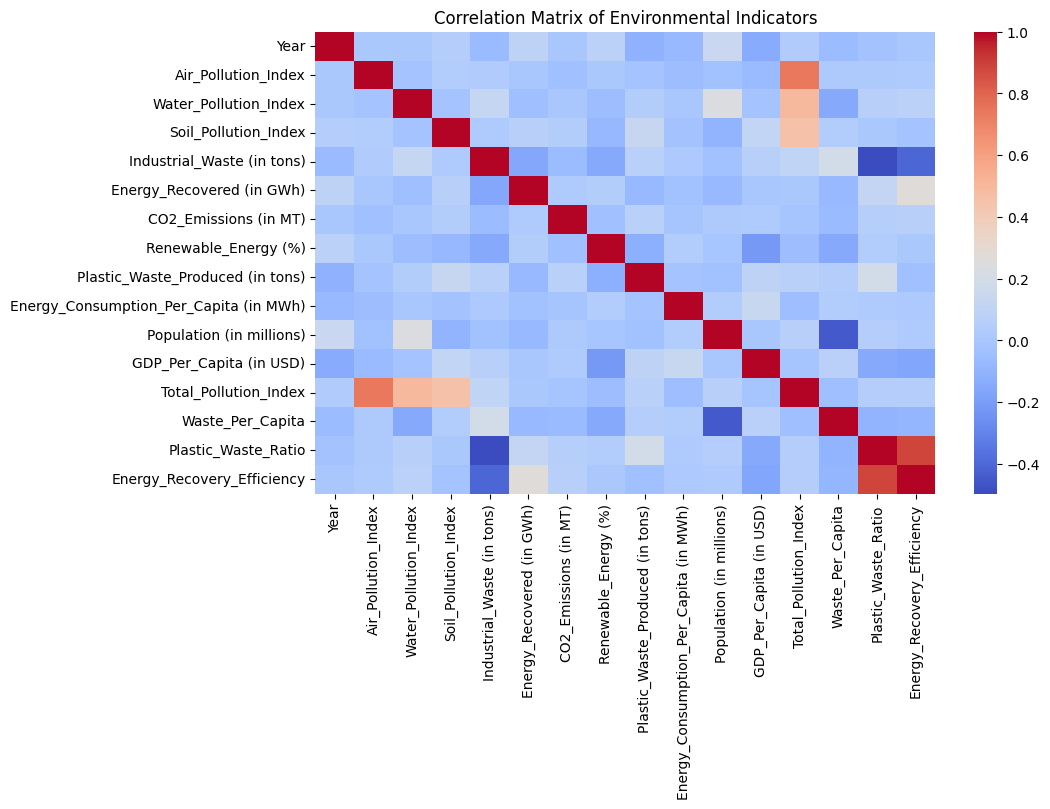

In [79]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Correlation Matrix of Environmental Indicators")

plt.show()

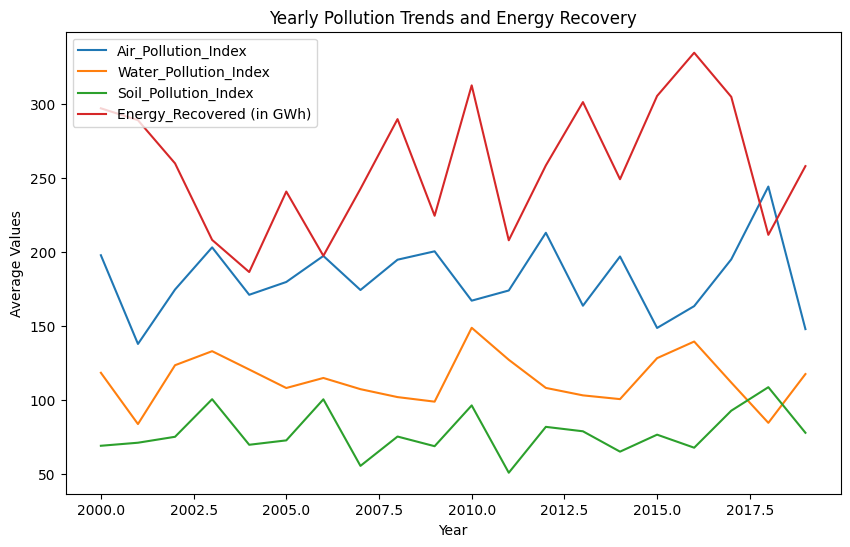

In [80]:
yearly_trends = df.groupby("Year")[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Energy_Recovered (in GWh)"
]].mean()

yearly_trends.plot(figsize=(10,6))

plt.title("Yearly Pollution Trends and Energy Recovery")

plt.xlabel("Year")

plt.ylabel("Average Values")

plt.show()

In [81]:
cluster_features = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Total_Pollution_Index",
    "Industrial_Waste (in tons)",
    "Renewable_Energy (%)",
    "Energy_Consumption_Per_Capita (in MWh)"
]

X_cluster = df[cluster_features]

In [82]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

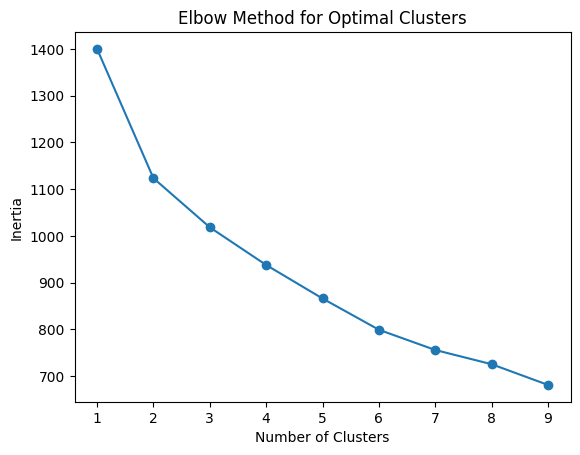

In [83]:
inertia = []

for k in range(1,10):

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker="o")

plt.title("Elbow Method for Optimal Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [84]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

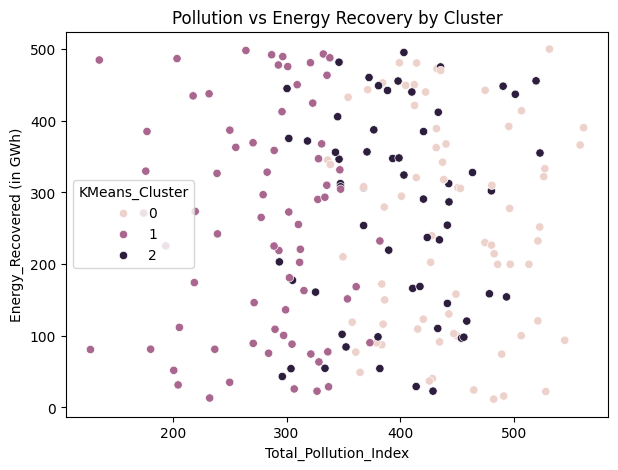

In [85]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Total_Pollution_Index",
    y="Energy_Recovered (in GWh)",
    hue="KMeans_Cluster",
    data=df
)

plt.title("Pollution vs Energy Recovery by Cluster")

plt.show()

In [86]:
cluster_summary = df.groupby("KMeans_Cluster")[[
    "Air_Pollution_Index",
    "Industrial_Waste (in tons)",
    "Energy_Recovered (in GWh)",
    "Renewable_Energy (%)"
]].mean()

cluster_summary

,Air_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),Renewable_Energy (%)
KMeans_Cluster,,,,
0,207.720000,65857.879000,252.094143,27.626286
1,124.704507,50986.981690,256.877324,27.758592
2,215.779153,39800.153729,274.658644,28.054915


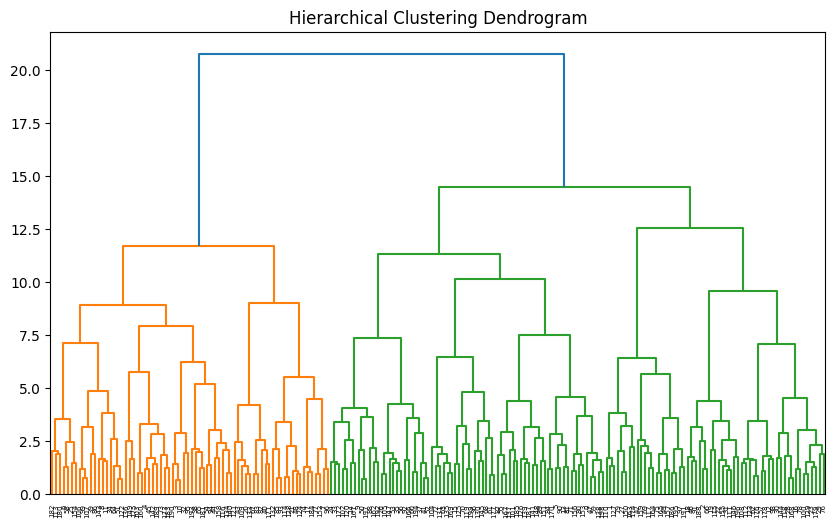

In [87]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [88]:
hc = AgglomerativeClustering(n_clusters=3)

df["Hierarchical_Cluster"] = hc.fit_predict(X_scaled)

In [89]:
features = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)",
    "Plastic_Waste_Produced (in tons)",
    "Energy_Consumption_Per_Capita (in MWh)",
    "Total_Pollution_Index"
]

X = df[features]

y = df["Energy_Recovered (in GWh)"]

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [91]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [92]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Linear Regression Results")

print("R2:", r2_score(y_test, lr_pred))

print("MSE:", mean_squared_error(y_test, lr_pred))

print("MAE:", mean_absolute_error(y_test, lr_pred))

Linear Regression Results
R2: -0.07768377469617649
MSE: 26060.803989980373
MAE: 142.67632896000202


In [93]:
model = Sequential()

model.add(Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)))

model.add(Dense(32, activation="relu"))

model.add(Dense(16, activation="relu"))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

c:\Users\mohda\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [94]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=60,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 94739.0859 - mae: 272.2581 - val_loss: 77080.0469 - val_mae: 238.2325
Epoch 2/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 94355.1875 - mae: 271.5468 - val_loss: 76698.1250 - val_mae: 237.4064
Epoch 3/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 93709.4531 - mae: 270.3510 - val_loss: 75913.0078 - val_mae: 235.7326
Epoch 4/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 92334.3672 - mae: 267.8575 - val_loss: 74381.9219 - val_mae: 232.4921
Epoch 5/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 89853.4375 - mae: 263.2183 - val_loss: 71670.8438 - val_mae: 226.6035
Epoch 6/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 85668.9453 - mae: 255.4106 - val_loss: 67261.6484 - val_mae: 216.6924
Epoch 7/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 79170.3516 - mae: 242.8880 - val_loss: 60716.6172 - val_mae: 202.4931
Epoch 8/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 69546.9844 - mae: 224.2606 - val_loss: 51898.

In [95]:
nn_pred = model.predict(X_test_scaled)

nn_pred = nn_pred.flatten()

print("Neural Network Results")

print("R2:", r2_score(y_test, nn_pred))

print("MSE:", mean_squared_error(y_test, nn_pred))

print("MAE:", mean_absolute_error(y_test, nn_pred))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002490BE6B920> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Neural Network Results
R2: -0.22944656846066258
MSE: 29730.76777168722
MAE: 150.52048690795897


In [96]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, nn_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, nn_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, nn_pred)
    ]
})

comparison = comparison.round(3)

comparison

,Model,R2 Score,MSE,MAE
0,Linear Regression,-0.078,26060.804,142.676
1,Neural Network,-0.229,29730.768,150.520


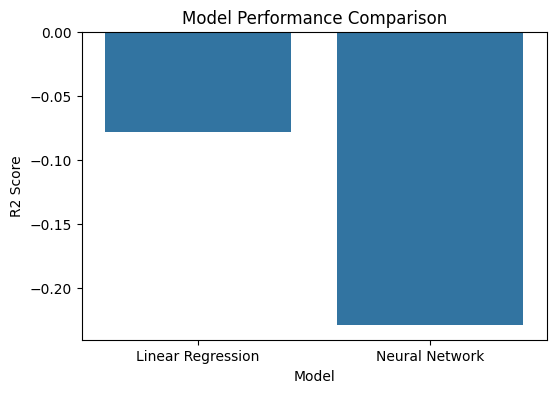

In [97]:
plt.figure(figsize=(6,4))

sns.barplot(x="Model", y="R2 Score", data=comparison)

plt.title("Model Performance Comparison")

plt.show()

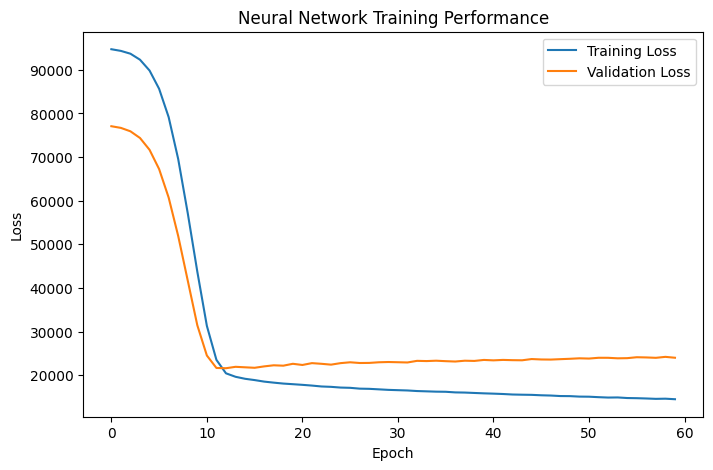

In [98]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Neural Network Training Performance")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

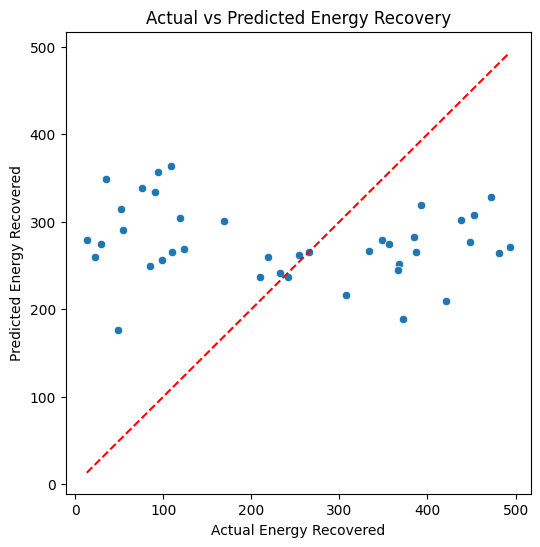

In [99]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y_test, y=nn_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Energy Recovered")

plt.ylabel("Predicted Energy Recovered")

plt.title("Actual vs Predicted Energy Recovery")

plt.show()



## Actionable Insights

### 1. Investment in Waste-to-Energy Technologies
Countries with high industrial waste but relatively low energy recovery should invest in **waste-to-energy technologies**. These systems can convert industrial waste into electricity, helping reduce environmental pollution while generating additional energy resources.

---

### 2. Promote Renewable Energy Adoption
Clusters with higher renewable energy percentages tend to show **lower pollution levels**. Governments should encourage **renewable energy expansion**, including solar, wind, and hydroelectric energy, to reduce dependence on fossil fuels.

---

### 3. Strengthen Industrial Waste Management Policies
Countries experiencing higher pollution levels should implement **stricter industrial waste management regulations**, encourage recycling programs, and adopt cleaner production technologies to reduce environmental impact.

---

### 4. Encourage Sustainable Energy Policies
Policy makers should promote **energy-efficient technologies and cleaner industrial practices** to balance economic development with environmental sustainability.

---

## Final Conclusion

Overall, the clustering analysis reveals distinct environmental patterns among countries based on pollution indicators and energy recovery performance. While predictive models show limited accuracy due to the complex relationship between pollution variables and energy recovery, the analysis highlights the importance of **waste-to-energy technologies, renewable energy adoption, and stronger environmental policies** in improving sustainability outcomes.